<a href="https://colab.research.google.com/github/ashwika232/wafer_map/blob/main/wafer_map_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub opencv-python scikit-learn tensorflow -q

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import cv2
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

In [ ]:
path = kagglehub.dataset_download("qingyi/wm811k-wafer-map")
print("Path:", path)
!ls {path}

100%|██████████| 149M/149M [00:04<00:00, 33.4MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1
LSWMD.pkl


In [ ]:
class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("pandas"):
            module = module.replace("pandas.indexes", "pandas.core.indexes")
        return super().find_class(module, name)

file_path = os.path.join(path, "LSWMD.pkl")

with open(file_path, "rb") as f:
    data = CustomUnpickler(f, encoding='latin1').load()

print(type(data))
print(data.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [ ]:
X = []
y = []

for i in range(len(data)):
    label = data['failureType'].iloc[i]

    if pd.notna(label):
        try:
            img = np.array(data['waferMap'].iloc[i])

            if img.size == 0:
                continue

            img = cv2.resize(img, (64, 64))

            X.append(img)
            y.append(str(label).strip().lower())

        except:
            continue

X = np.array(X)
y = np.array(y)

print("Samples:", len(X))
print("Classes:", set(y))

/tmp/ipykernel_983/1816487654.py:7: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if pd.notna(label):


Samples: 172950
Classes: {np.str_("[['scratch']]"), np.str_("[['random']]"), np.str_("[['edge-loc']]"), np.str_("[['center']]"), np.str_("[['near-full']]"), np.str_("[['loc']]"), np.str_("[['none']]"), np.str_("[['edge-ring']]"), np.str_("[['donut']]")}


In [ ]:
X = []
y = []

for i in range(len(data)):
    label = data['failureType'].iloc[i]

    if pd.notna(label):
        try:

            label = label[0][0]

            img = np.array(data['waferMap'].iloc[i])

            if img.size == 0:
                continue

            img = cv2.resize(img, (64, 64))

            X.append(img)
            y.append(label.lower())

        except:
            continue

X = np.array(X)
y = np.array(y)

print("Samples:", len(X))
print("Classes:", set(y))

/tmp/ipykernel_983/3280792386.py:7: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if pd.notna(label):


Samples: 172950
Classes: {np.str_('random'), np.str_('none'), np.str_('scratch'), np.str_('near-full'), np.str_('edge-loc'), np.str_('loc'), np.str_('edge-ring'), np.str_('center'), np.str_('donut')}


In [ ]:
# remove unwanted classes
mask = (y != 'near-full')
X = X[mask]
y = y[mask]

print("After removal:", set(y))

After removal: {np.str_('random'), np.str_('none'), np.str_('scratch'), np.str_('edge-loc'), np.str_('loc'), np.str_('edge-ring'), np.str_('center'), np.str_('donut')}


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print("Final labels:", np.unique(y))
print("Classes:", len(np.unique(y)))

Final labels: [0 1 2 3 4 5 6 7]
Classes: 8


In [ ]:
X = X[:8000]
y = y[:8000]

print("Final size:", X.shape)

Final size: (8000, 64, 64)


In [ ]:


X = X / 255.0
X = X.reshape(-1, 64, 64, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)

Train: (6400, 64, 64, 1)


In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, ReLU, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(64,64,1)),

    Conv2D(16, (3,3), padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D(),

    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D(),

    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D(),

    Flatten(),

    Dense(256, name="feature_layer"),   # 🔥 stronger features
    ReLU(),
    Dropout(0.4),

    Dense(8, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9305 - loss: 0.3570 - val_accuracy: 0.8000 - val_loss: 1.5322
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9600 - loss: 0.1629 - val_accuracy: 0.8000 - val_loss: 1.3170
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9667 - loss: 0.1285 - val_accuracy: 0.7906 - val_loss: 1.0288
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9708 - loss: 0.1028 - val_accuracy: 0.9287 - val_loss: 0.2915
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9772 - loss: 0.0837 - val_accuracy: 0.8031 - val_loss: 2.8140
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9784 - loss: 0.0756 - val_accuracy: 0.2069 - val_loss: 2.0593
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9789 - loss: 0.0710 - val_accuracy: 0.0188 - val_loss: 19.3782


In [ ]:
feature_model = Model(
    inputs=model.inputs,
    outputs=model.get_layer("feature_layer").output
)

X_train_feat = feature_model.predict(X_train)
X_test_feat = feature_model.predict(X_test)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
from sklearn.multiclass import OutputCodeClassifier
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10, gamma='scale')

ecoc = OutputCodeClassifier(svm, code_size=3)

ecoc.fit(X_train_feat, y_train)

y_pred = ecoc.predict(X_test_feat)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.965625
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.33      1.00      0.50         1
           2       0.79      0.39      0.53        38
           3       1.00      0.99      0.99       208
           4       0.93      0.42      0.58        31
           5       0.97      1.00      0.98      1280
           6       0.97      0.97      0.97        29
           7       0.00      0.00      0.00         6

    accuracy                           0.97      1600
   macro avg       0.75      0.65      0.64      1600
weighted avg       0.96      0.97      0.96      1600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


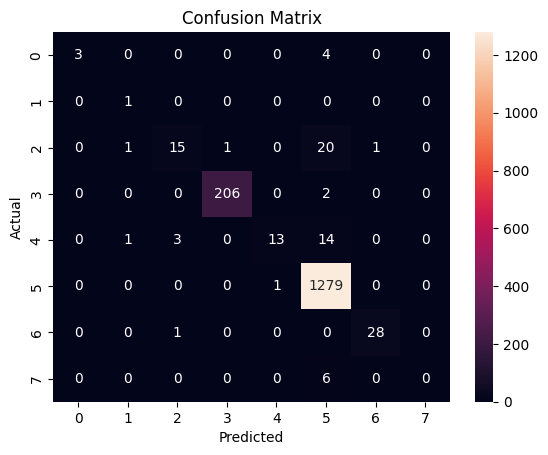

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

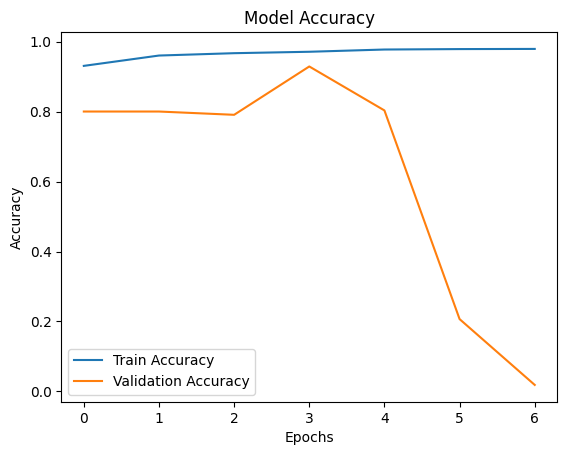

In [ ]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")

plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,223,450 (12.30 MB)

 Trainable params: 1,074,408 (4.10 MB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 2,148,818 (8.20 MB)

In [ ]:
feature_model = Model(
    inputs=model.inputs,
    outputs=model.get_layer("feature_layer").output
)

X_train_feat = feature_model.predict(X_train)
X_test_feat = feature_model.predict(X_test)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
